# Análisis predictivo de datos — Evaluación 1

## Objetivo

Construir un modelo de aprendizaje automático para predecir **Weight (peso)** de los atletas.

Como `Weight` es una variable cuantitativa continua, se utilizará un modelo de **regresión lineal**. Antes de entrenarlo se realizará una revisión sencilla de los datos para seleccionar las variables que tengan sentido como predictoras y evitar variables redundantes, identificadoras o con demasiadas categorías.

> **Fuente de datos:** `athlete_events.csv`.

## 1. Carga y preparación de los datos

Primero se carga el archivo y se revisa su estructura.

Se eliminan los registros duplicados. También se descartan `ID` y `Name`, ya que identifican al atleta y no aportan una característica útil para predecir su peso.

Para el modelo se conservan las variables que pueden aportar información sobre el atleta, su participación y el contexto de los Juegos. `Weight` será la variable objetivo, por lo que se eliminan los registros donde no está disponible.

Los valores faltantes de las variables predictoras no se eliminan: se completarán más adelante dentro del proceso de modelado.

In [3]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = "athlete_events.csv"

raw = pd.read_csv(DATA_PATH)
registros_originales = len(raw)

raw["Medal"] = raw["Medal"].fillna("No medal")
raw = raw.drop_duplicates().copy()

df = raw.dropna(subset=["Weight"]).copy()

discarded = ["ID", "Name", "NOC", "Games", "City", "Event"]
model_df = df.drop(columns=discarded).copy()

print(f"Registros: {registros_originales:,} → {len(raw):,} después de duplicados → {len(model_df):,} para el modelo")

display(model_df.isna().sum().to_frame("valores faltantes"))

X = model_df.drop(columns="Weight")
y = model_df["Weight"]

nominal_features = ["Sex", "Team", "Sport", "Season", "Medal"]
ordinal_features = ["Year"]
numeric_features = ["Age", "Height"]

Registros: 271,116 → 269,731 después de duplicados → 208,204 para el modelo


,valores faltantes
Sex,0
Age,862
Height,1364
Weight,0
Team,0
Year,0
Season,0
Sport,0
Medal,0


## 2. Variables categóricas

Las variables categóricas son:

- `Sex`
- `Team`
- `Sport`
- `Season`
- `Medal`

`Team` tiene muchas categorías, por lo que se excluye de la primera versión del modelo. Esto permite evitar una representación demasiado grande y reducir el riesgo de que el modelo aprenda patrones demasiado específicos.

`Medal` se transforma en una categoría llamada **No medal** cuando originalmente estaba vacía. Así, el valor faltante se interpreta como ausencia de medalla.

Las variables categóricas que sí se utilicen se convertirán posteriormente a variables numéricas mediante **One-Hot Encoding**.

In [4]:
categorical_columns = model_df.select_dtypes(include="object").columns.tolist()

cardinality = (
    model_df[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("número de categorías")
)

display(cardinality)

,número de categorías
Team,680
Sport,56
Medal,4
Sex,2
Season,2


## 3. Variables cuantitativas

Las variables numéricas que se revisan son `Age`, `Height`, `Weight` y `Year`.

- `Height` presenta una relación fuerte con `Weight`.
- `Age` presenta una relación positiva más moderada.
- `Year` tiene una relación lineal muy baja con el peso.
- `Weight` es la variable objetivo.

También se revisan valores atípicos. Estos no se eliminan automáticamente, porque pueden representar atletas reales con características poco frecuentes.

In [5]:
quantitative_columns = ["Age", "Height", "Weight", "Year"]

quantitative_summary = (
    model_df[quantitative_columns]
    .agg(["count", "mean", "std", "min", "median", "max"])
    .T
)

quantitative_summary["asimetría"] = model_df[quantitative_columns].skew()

outlier_counts = {}
for column in quantitative_columns:
    values = model_df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    outlier_counts[column] = int(
        ((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()
    )

quantitative_summary["atípicos_IQR"] = pd.Series(outlier_counts)

display(quantitative_summary.round(2))

,count,mean,std,min,median,max,asimetría,atípicos_IQR
Age,207342.0,25.06,5.48,11.0,24.0,71.0,1.14,4656
Height,206840.0,175.36,10.54,127.0,175.0,226.0,0.02,1320
Weight,208204.0,70.70,14.35,25.0,70.0,214.0,0.80,3237
Year,208204.0,1989.39,20.44,1896.0,1992.0,2016.0,-0.99,3435


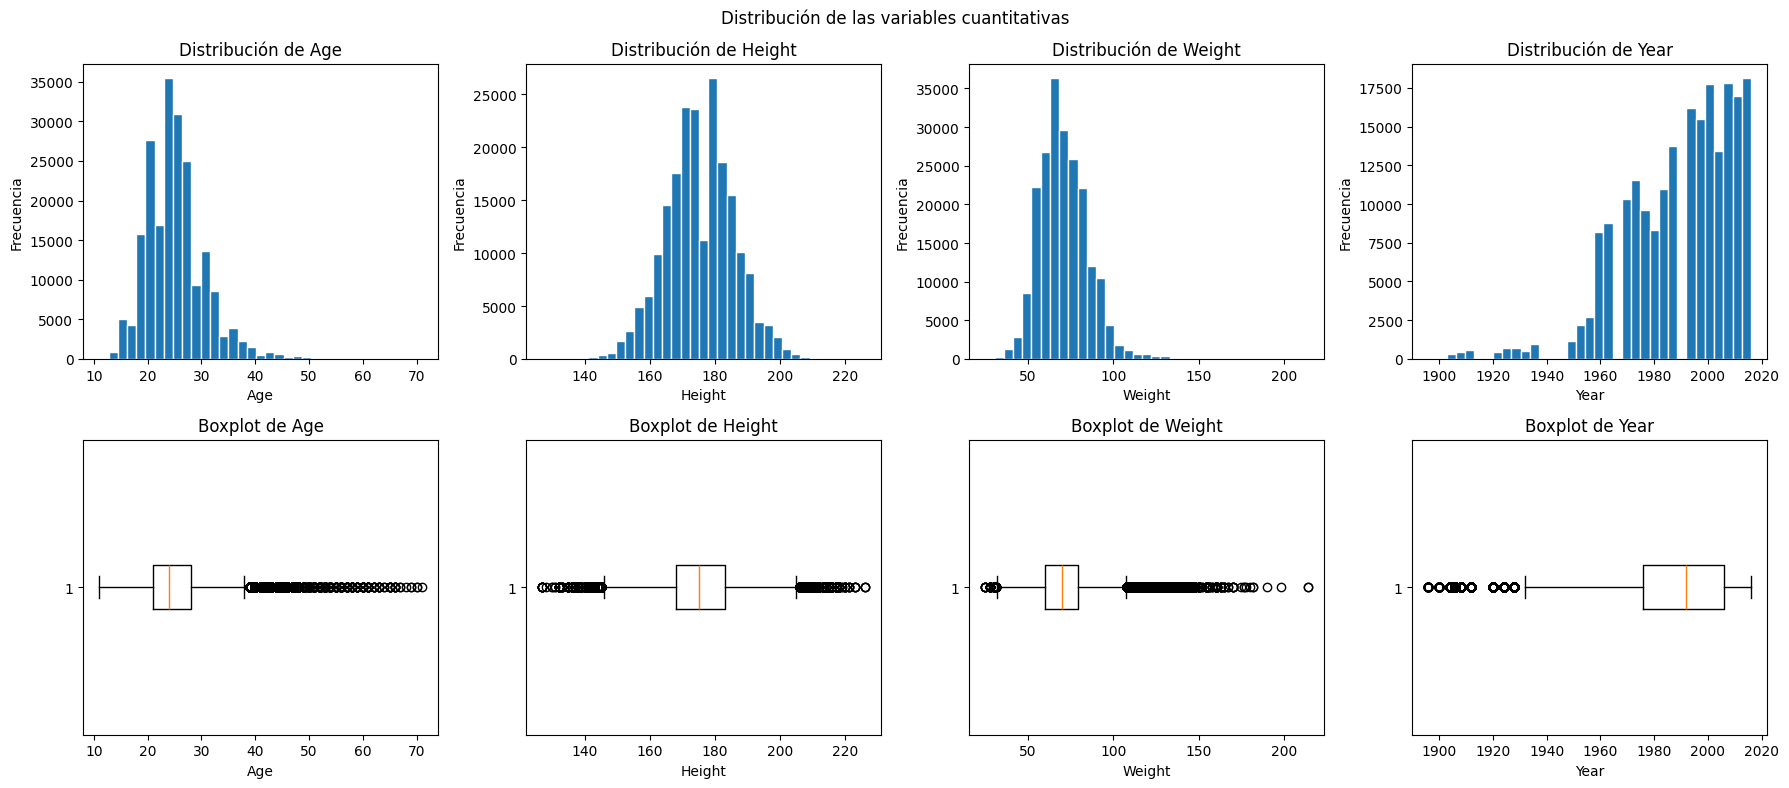

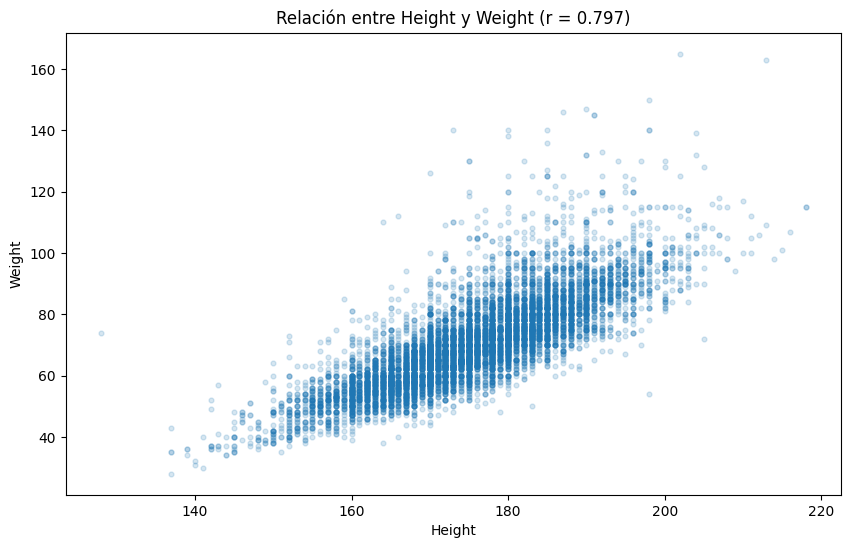

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for index, column in enumerate(["Age", "Height", "Weight", "Year"]):
    values = model_df[column].dropna()

    axes[0, index].hist(values, bins=35, edgecolor="white")
    axes[0, index].set_title(f"Distribución de {column}")
    axes[0, index].set_xlabel(column)
    axes[0, index].set_ylabel("Frecuencia")

    axes[1, index].boxplot(values, vert=False)
    axes[1, index].set_title(f"Boxplot de {column}")
    axes[1, index].set_xlabel(column)

fig.suptitle("Distribución de las variables cuantitativas")
plt.tight_layout()
plt.show()

scatter_data = (
    model_df[["Height", "Weight"]]
    .dropna()
    .sample(n=min(10000, model_df[["Height", "Weight"]].dropna().shape[0]), random_state=1)
)

correlation = scatter_data["Height"].corr(scatter_data["Weight"])

plt.figure(figsize=(10, 6))
plt.scatter(scatter_data["Height"], scatter_data["Weight"], alpha=0.18, s=12)
plt.title(f"Relación entre Height y Weight (r = {correlation:.3f})")
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()

## 4. Relación entre las variables y Weight

La relación más importante entre las variables numéricas es la de `Height` con `Weight`, con una correlación de aproximadamente **0.80**.

También se observa una relación positiva, aunque menor, entre `Age` y `Weight`. `Year` presenta una relación prácticamente nula.

En las variables categóricas, `Sex` y `Sport` muestran diferencias claras en el peso promedio. Por ejemplo, el peso promedio observado es mayor en hombres que en mujeres, y existen diferencias entre deportes.

Por esto, la primera versión del modelo utilizará `Sex`, `Season`, `Sport`, `Year` y `Height`.

In [7]:
numeric_correlations = (
    model_df.select_dtypes(include="number")
    .corr()["Weight"]
    .sort_values(ascending=False)
)

display(numeric_correlations.to_frame("correlación").round(3))

grouped_means = pd.concat(
    {
        column: model_df.groupby(column, observed=True)["Weight"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
        .head(10)
        for column in ["Sex", "Season", "Sport", "Medal"]
    },
    names=["variable", "categoría"]
)

display(grouped_means.round(2))

,correlación
Weight,1.000
Height,0.796
Age,0.212
Year,0.019


count   mean
variable categoría                          
Sex      M                     141433  75.74
         F                      66771  60.02
Season   Summer                168661  70.69
         Winter                 39543  70.76
Sport    Athletics              32601  69.25
         Swimming               18804  70.59
         Gymnastics             18335  56.92
         Rowing                  7933  80.04
         Cycling                 7829  70.07
         Cross Country Skiing    7537  65.88
         Shooting                7300  74.03
         Fencing                 6540  71.39
         Alpine Skiing           6350  72.07
         Canoeing                5552  76.49
Medal    No medal              177748  70.18
         Gold                   10254  74.18
         Bronze                 10227  73.48
         Silver                  9975  73.64

## 5. Preparación de los datos y primer modelo

Se utilizará **regresión lineal**, porque `Weight` es un valor numérico continuo.

Las variables categóricas se convierten a variables numéricas mediante One-Hot Encoding. Para los valores faltantes se utiliza:

- **Mediana** para las variables numéricas.
- **Categoría más frecuente** para las variables categóricas.

Finalmente, las variables numéricas se escalan.

Todo este proceso se realiza dentro de un `Pipeline`, de manera que las transformaciones se calculan únicamente con los datos de entrenamiento y no con los datos de prueba.

In [8]:
base_features = ["Sex", "Season", "Sport", "Year", "Height"]
base_nominal = ["Sex", "Season", "Sport"]
base_numeric = ["Year", "Height"]

X_train, X_test, y_train, y_test = train_test_split(
    X[base_features],
    y,
    test_size=0.20,
    random_state=1
)

def make_preprocessor(nominal, numeric):
    return ColumnTransformer(
        transformers=[
            (
                "nominal",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore"))
                ]),
                nominal
            ),
            (
                "numeric",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numeric
            )
        ],
        remainder="drop"
    )

model_v1 = Pipeline([
    ("preprocessing", make_preprocessor(base_nominal, base_numeric)),
    ("model", LinearRegression())
])

model_v1.fit(X_train, y_train)

train_pred = model_v1.predict(X_train)
test_pred = model_v1.predict(X_test)

metrics_v1 = pd.DataFrame({
    "R²": [r2_score(y_test, test_pred)],
    "RMSE": [mean_squared_error(y_test, test_pred) ** 0.5],
    "MAE": [mean_absolute_error(y_test, test_pred)]
}, index=["Prueba"])

display(metrics_v1.round(4))

,R²,RMSE,MAE
Prueba,0.7175,7.6693,5.2589


### Resultado del primer modelo

El modelo obtiene un **R² de aproximadamente 0.72 en prueba**, lo que indica que explica una parte importante de la variación observada en `Weight`.

Además, el resultado de entrenamiento y prueba es bastante similar, por lo que no se observa una diferencia grande entre ambos conjuntos.

Para comprobar si se puede mejorar el resultado, se añade `Age` y `Medal` en una segunda versión.

In [9]:
expanded_features = base_features + ["Age", "Medal"]
expanded_nominal = base_nominal + ["Medal"]
expanded_numeric = base_numeric + ["Age"]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X[expanded_features],
    y,
    test_size=0.20,
    random_state=1
)

model_v2 = Pipeline([
    ("preprocessing", make_preprocessor(expanded_nominal, expanded_numeric)),
    ("model", LinearRegression())
])

model_v2.fit(X_train_2, y_train_2)

train_pred_2 = model_v2.predict(X_train_2)
test_pred_2 = model_v2.predict(X_test_2)

metrics_v2 = pd.DataFrame({
    "R²": [r2_score(y_test_2, test_pred_2)],
    "RMSE": [mean_squared_error(y_test_2, test_pred_2) ** 0.5],
    "MAE": [mean_absolute_error(y_test_2, test_pred_2)]
}, index=["Prueba"])

display(metrics_v2.round(4))
model_v2

,R²,RMSE,MAE
Prueba,0.7207,7.6254,5.2287


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Season', 'Sport',
                                                   'Medal']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Year', 'Height', 'Age'])])),
                ('model', LinearRegression())])

In [14]:
feature_names = model_v2.named_steps["preprocessing"].get_feature_names_out()

print(f"Total features: {len(feature_names)}")
for f in feature_names:
    print(f)

Total features: 67
nominal__Sex_F
nominal__Sex_M
nominal__Season_Summer
nominal__Season_Winter
nominal__Sport_Alpine Skiing
nominal__Sport_Archery
nominal__Sport_Art Competitions
nominal__Sport_Athletics
nominal__Sport_Badminton
nominal__Sport_Baseball
nominal__Sport_Basketball
nominal__Sport_Beach Volleyball
nominal__Sport_Biathlon
nominal__Sport_Bobsleigh
nominal__Sport_Boxing
nominal__Sport_Canoeing
nominal__Sport_Cross Country Skiing
nominal__Sport_Curling
nominal__Sport_Cycling
nominal__Sport_Diving
nominal__Sport_Equestrianism
nominal__Sport_Fencing
nominal__Sport_Figure Skating
nominal__Sport_Football
nominal__Sport_Freestyle Skiing
nominal__Sport_Golf
nominal__Sport_Gymnastics
nominal__Sport_Handball
nominal__Sport_Hockey
nominal__Sport_Ice Hockey
nominal__Sport_Judo
nominal__Sport_Lacrosse
nominal__Sport_Luge
nominal__Sport_Modern Pentathlon
nominal__Sport_Motorboating
nominal__Sport_Nordic Combined
nominal__Sport_Rhythmic Gymnastics
nominal__Sport_Rowing
nominal__Sport_Rugby


## 6. Comparación y conclusión

La segunda versión mejora ligeramente el resultado:

- **R² de prueba:** pasa de aproximadamente 0.718 a 0.721.
- **RMSE de prueba:** baja de aproximadamente 7.669 a 7.625.
- **MAE de prueba:** baja de aproximadamente 5.259 a 5.229.

La mejora es pequeña, pero indica que `Age` y `Medal` aportan información adicional.

### Conclusión

El modelo final es una **regresión lineal** con las variables `Sex`, `Season`, `Sport`, `Year`, `Height`, `Age` y `Medal`.

El resultado en prueba es aproximadamente **R² = 0.721**, **RMSE = 7.625** y **MAE = 5.229**.

En términos sencillos, el modelo consigue explicar cerca del **72 % de la variación del peso** en los datos de prueba. La variable que más destaca individualmente es `Height`, mientras que `Sex`, `Sport` y `Age` también aportan información.

`Team` no se incluye en esta versión debido a su alta cantidad de categorías. Las variables identificadoras o que aportan información redundante para este planteamiento (`ID`, `Name`, `NOC`, `Games`, `City` y `Event`) fueron descartadas antes del entrenamiento.